# **Fund book: 12-config search for a steadier Halal blend**

Paper 07 ran one blend — 40% FCF quality, 40% ROIC compounders, 20% dual momentum, optional 10% SUE — and it did **not** deliver steadier growth. That book tracked FCF, lost more than SPUS in 2022, and dual momentum as a 20% sleeve missed 2023 (about +3% vs FCF +33%). This notebook does not invent new selectors. It asks which **combination** of those same frozen sleeves is the live 1B book.

After banned businesses and point-in-time AAOIFI screens, the sleeves are unchanged:

1. **FCF quality** (paper 01) — top half of Halal names by free-cash-flow margin, cap-weighted, monthly
2. **ROIC compounders** (paper 02) — ROIC above 15% then top half by reinvestment, cap-weighted, monthly
3. **Dual-momentum regime** (paper 04) — top quintile 12–1 relative strength; **that sleeve** holds cash when SPY is below its 200-day SMA
4. **SUE satellite** (paper 06) — robust SUE `> 2σ`, t+1 entry, 21-day equal-weight hold. Event rules stay frozen; only the **book weight** is 0% or 10%

High-beta (paper 05) stays out. We do **not** grid-search fine weights and we do **not** use Monte Carlo to pick a winner. One 2020 crash and one 2022 bear are the test, not noise to shuffle.

**What stays frozen:** universe, AAOIFI ratios, each sleeve’s live knobs, SUE event definition, 10 bp one-way cost, 2% risk-free rate, SPY and SPUS as benchmarks.

**What we change (one thing at a time):** which sleeves are on, coarse weights (100 / 50–50 / 70–30 / +20% dual mom / +10% SUE), where the SMA sits (off vs whole NAV), then one name-cap pass (8% and 10%).

**Train / test (locked before looking at results):**

| Split | Dates | Job |
| --- | --- | --- |
| Train | 2020-01-01 → 2022-12-31 | Survive the crash and the bear |
| Test | 2023-01-01 → 2024-12-31 | The brake must not kill the recovery |
| Report | 2019-12-19 → 2024-12-31 | One full-sample table |

**Kill rules (a book is out if any fire):**

1. Train: 2022 calendar return more than **5 points worse** than SPUS
2. Train: max drawdown **worse than SPUS**
3. Train: Calmar below **both** FCF-only and SPUS
4. Test: 2023 calendar return more than **15 points worse** than FCF-only

ROIC-only cannot be the engine: it barely exists in train. Rank survivors by **train Calmar**, then confirm on test. Do not retune after test.

**The 12 configs**

| # | Set | Book |
| --- | --- | --- |
| 1 | A engine | FCF 100% |
| 2 | A engine | ROIC 100% (report only) |
| 3 | A engine | FCF 50 / ROIC 50 |
| 4 | A engine | FCF 70 / ROIC 30 |
| 5 | B sleeve brake | Winner of A + 20% dual momentum (others scaled to 80%) |
| 6 | B control | Winner of A, dual momentum 0% |
| 7 | C NAV brake | Winner of A, `throttle="spy_sma"` on the whole book, dual mom weight 0 |
| 8 | C NAV brake | FCF 100%, same whole-book SMA |
| 9 | D satellite | Best of A–C that still passes kills, SUE 10% (others scaled to 90%) |
| 10 | D control | Same book, SUE 0% |
| 11 | E cap | Winner so far, `name_cap=0.08` |
| 12 | E cap | Winner so far, `name_cap=0.10` |

**White-paper question:** is the live book an FCF (or FCF+ROIC) engine with a **book-level** SMA brake and an optional SUE satellite — or does 20% dual momentum inside the mix still earn its seat?

**What this notebook does, in plain terms:** reuse paper 07’s cached universe, prices, ROIC history, and SUE events; run the 12 books on the same lab; apply the kill rules; write one CSV and pick a single survivor.


## Setup

Same environment as `code.ipynb`. Metrics and prices come from `halalquant` with `cache=True`. ROIC history and SUE events load from `cache/` written by the paper 07 run. Set `FAST_MODE = True` only to smoke-test the loop.


In [1]:
import os
import subprocess
import sys
from pathlib import Path

from IPython.display import display


def resolve_notebook_dir() -> Path:
    candidates = [Path.cwd()]
    candidates.append(
        Path.home() / "Documents/Development/Monterey-Finance/Research/papers/07-book-construction"
    )
    for path in candidates:
        try:
            resolved = path.resolve()
        except OSError:
            continue
        if resolved.is_dir() and (resolved / "code.ipynb").exists():
            return resolved
    return Path.cwd()


NB_DIR = resolve_notebook_dir()
os.chdir(NB_DIR)

REPO_ROOT = NB_DIR.parents[2]
RESEARCH_ROOT = NB_DIR.parents[1]
HQ_ROOT = REPO_ROOT.parent / "halalquant"
PIP_DEPS = ["yfinance", "matplotlib", "requests", "pyarrow", "duckdb"]

if HQ_ROOT.is_dir() and (HQ_ROOT / "pyproject.toml").exists():
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-e", f"{HQ_ROOT}[cache]"],
        cwd=str(NB_DIR),
        check=False,
    )
    hq_src = str(HQ_ROOT)
    if hq_src not in sys.path:
        sys.path.insert(0, hq_src)
else:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "halalquant[cache]"] + PIP_DEPS,
        cwd=str(NB_DIR),
        check=False,
    )

subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + PIP_DEPS, cwd=str(NB_DIR), check=False)

research_src = str(RESEARCH_ROOT)
if research_src not in sys.path:
    sys.path.insert(0, research_src)

import importlib
import sleeves
import sleeves.book
import sleeves.compliance
import sleeves.fundamentals
import sleeves.lab
import sleeves.select

importlib.reload(sleeves.compliance)
importlib.reload(sleeves.fundamentals)
importlib.reload(sleeves.select)
importlib.reload(sleeves.book)
importlib.reload(sleeves.lab)
importlib.reload(sleeves)

os.environ.setdefault(
    "HALALQUANT_SEC_UA",
    "Monterey Finance Research halalquant/0.1.0 research@montereyfinance.com",
)

import warnings

import halalquant as hq
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sleeves import FrozenRules, Lab, calc_performance_stats, stats_table
from sleeves.universe import apply_sector_screen, load_sp500_tickers

warnings.filterwarnings("ignore", category=FutureWarning)

START = "2019-12-19"
END = "2024-12-31"
PRICE_START = "2018-01-01"
REBALANCE_FREQ = "ME"
FAST_MODE = False
RISK_FREE_RATE = 0.02
COST_BPS = 10

TRAIN_START = "2020-01-01"
TRAIN_END = "2022-12-31"
TEST_START = "2023-01-01"
TEST_END = "2024-12-31"

KILL_2022_GAP = 0.05
KILL_2023_GAP = 0.15
MIN_TRAIN_DAYS_FOR_ENGINE = 252

BENCHMARKS = {"S&P 500": "SPY", "Halal (SPUS)": "SPUS"}

CACHE_DIR = NB_DIR / "cache"
FIG_DIR = NB_DIR / "figures" / "blend-search"
OUT_CSV = CACHE_DIR / "blend_search_results.csv"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"notebook dir: {NB_DIR}")
print(f"halalquant v{hq.__version__} from {Path(hq.__file__).resolve().parent.parent}")
print(f"sleeves from {RESEARCH_ROOT / 'sleeves'}")
print(f"Train {TRAIN_START} → {TRAIN_END}  Test {TEST_START} → {TEST_END}  FAST_MODE={FAST_MODE}")



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


notebook dir: /Users/raoabdul/Documents/Development/Monterey-Finance/Research/papers/07-book-construction
halalquant v0.1.0 from /Users/raoabdul/Documents/Development/halalquant
sleeves from /Users/raoabdul/Documents/Development/Monterey-Finance/Research/sleeves
Train 2020-01-01 → 2022-12-31  Test 2023-01-01 → 2024-12-31  FAST_MODE=False


## Step 1 — Load the paper 07 universe and frames

Sector screen on the current S&P 500, then the same metrics / prices / ROIC / SUE panels. No new Yahoo loops if `cache/` already has ROIC and SUE parquet.


In [2]:
raw_universe = load_sp500_tickers()
if FAST_MODE:
    raw_universe = raw_universe[:60]
    print("FAST_MODE is on — smoke-test universe only.\n")

eligible_universe, sector_audit, activity_labels = apply_sector_screen(raw_universe)
print(f"Raw universe:        {len(raw_universe)} tickers")
print(f"After sector screen: {len(eligible_universe)} tickers")

rules = FrozenRules().with_book(
    sleeve_weights={"fcf_quality": 1.0},
    name_cap=None,
    throttle=None,
    collapse_share_classes=True,
    cost_bps=COST_BPS,
    risk_free_rate=RISK_FREE_RATE,
    rebalance_freq=REBALANCE_FREQ,
)
print("AAOIFI debt cap:", rules.aaoifi.debt_threshold)
print("FCF / ROIC / dual-mom / SUE knobs frozen from papers 01, 02, 04, 06")

metrics_path = CACHE_DIR / "metrics.parquet"
prices_path = CACHE_DIR / "prices.parquet"
all_symbols = sorted(set(eligible_universe) | set(BENCHMARKS.values()))

if metrics_path.exists() and prices_path.exists() and not FAST_MODE:
    metrics = pd.read_parquet(metrics_path)
    prices = pd.read_parquet(prices_path)
    prices["date"] = pd.to_datetime(prices["date"])
    print(f"Loaded cached metrics {metrics.shape} and prices {prices.shape}")
else:
    print("Fetching point-in-time AAOIFI metrics …")
    metrics = hq.get_financial_metrics(
        eligible_universe, start=START, end=END, freq=REBALANCE_FREQ, cache=True
    )
    print("Downloading prices …")
    prices = hq.download(all_symbols, start=PRICE_START, end=END, cache=True)
    prices["date"] = pd.to_datetime(prices["date"])
    if not FAST_MODE:
        metrics.to_parquet(metrics_path, index=False)
        prices.to_parquet(prices_path, index=False)
        print(f"  wrote {metrics_path.name} and {prices_path.name}")

print(f"  {metrics.shape[0]} snapshot rows, {metrics['symbol'].nunique()} symbols")
print(f"  {prices['symbol'].nunique()} price symbols, {prices['date'].nunique()} trading days")

roic_path = CACHE_DIR / "roic_history.parquet"
sue_path = CACHE_DIR / "sue_events.parquet"
if not roic_path.exists():
    raise FileNotFoundError(f"Missing {roic_path} — run code.ipynb Step 3 ROIC cell first.")
roic_history = pd.read_parquet(roic_path)
print(f"ROIC history: {roic_history['symbol'].nunique()} symbols")

if not sue_path.exists():
    raise FileNotFoundError(f"Missing {sue_path} — run code.ipynb SUE cell first.")
sue_events = pd.read_parquet(sue_path)
print(f"SUE events: {int(sue_events['sue'].notna().sum()) if 'sue' in sue_events.columns else 0} usable prints")

lab = Lab.from_frames(
    metrics=metrics,
    prices=prices,
    rules=rules,
    roic_history=roic_history,
    sue_events=sue_events,
    start=START,
    end=END,
)
print("Lab ready.")


Raw universe:        503 tickers
After sector screen: 440 tickers
AAOIFI debt cap: 0.3
FCF / ROIC / dual-mom / SUE knobs frozen from papers 01, 02, 04, 06
Fetching point-in-time AAOIFI metrics …
  wrote metrics.parquet and prices.parquet
  25600 snapshot rows, 431 symbols
  442 price symbols, 1761 trading days
ROIC history: 431 symbols
SUE events: 17504 usable prints
Lab ready.


## Step 2 — Scorekeeper

Each config is scored on train, test, and the full window. Kill rules are functions of **FCF-only** and **SPUS**, which we compute first.


In [3]:
def to_series(frame: pd.DataFrame) -> pd.Series:
    s = frame.dropna(subset=["return"]).set_index("date")["return"].astype(float)
    s.index = pd.to_datetime(s.index)
    return s.sort_index()


def slice_returns(s: pd.Series, start: str, end: str) -> pd.Series:
    return s[(s.index >= pd.Timestamp(start)) & (s.index <= pd.Timestamp(end))].dropna()


def calendar_return(s: pd.Series, year: int) -> float:
    sl = slice_returns(s, f"{year}-01-01", f"{year}-12-31")
    if sl.empty:
        return np.nan
    return float((1.0 + sl).prod() - 1.0)


def top5_weight(log: pd.DataFrame) -> float:
    if log is None or log.empty:
        return np.nan
    last = pd.to_datetime(log["as_of"]).max()
    snap = log[pd.to_datetime(log["as_of"]) == last]
    if snap.empty or "weight" not in snap.columns:
        return np.nan
    w = snap.groupby("symbol")["weight"].sum().sort_values(ascending=False)
    return float(w.head(5).sum())


def mean_jaccard(log: pd.DataFrame) -> float:
    if log is None or log.empty or "sleeve" not in log.columns:
        return np.nan
    if not {"fcf_quality", "roic"}.issubset(set(log["sleeve"].dropna().unique())):
        return np.nan
    rows = []
    for as_of, g in log.groupby("as_of"):
        a = set(g.loc[g["sleeve"] == "fcf_quality", "symbol"])
        b = set(g.loc[g["sleeve"] == "roic", "symbol"])
        if not a or not b:
            continue
        rows.append(len(a & b) / len(a | b))
    return float(np.mean(rows)) if rows else np.nan


def score_series(s: pd.Series, label: str) -> dict:
    full = slice_returns(s, START, END)
    train = slice_returns(s, TRAIN_START, TRAIN_END)
    test = slice_returns(s, TEST_START, TEST_END)
    full_stats = calc_performance_stats(full, label, rf=RISK_FREE_RATE)
    train_stats = calc_performance_stats(train, label, rf=RISK_FREE_RATE)
    test_stats = calc_performance_stats(test, label, rf=RISK_FREE_RATE)
    return {
        "config": label,
        "n_live_train": int(len(train)),
        "n_live_test": int(len(test)),
        "ret_2020": calendar_return(s, 2020),
        "ret_2022": calendar_return(s, 2022),
        "ret_2023": calendar_return(s, 2023),
        "ret_2024": calendar_return(s, 2024),
        "train_cagr": train_stats["CAGR"],
        "train_max_dd": train_stats["Max Drawdown"],
        "train_calmar": train_stats["Calmar"],
        "test_cagr": test_stats["CAGR"],
        "test_max_dd": test_stats["Max Drawdown"],
        "test_calmar": test_stats["Calmar"],
        "full_cagr": full_stats["CAGR"],
        "full_vol": full_stats["Volatility"],
        "full_sharpe": full_stats["Sharpe"],
        "full_max_dd": full_stats["Max Drawdown"],
        "full_calmar": full_stats["Calmar"],
    }


RUN_CACHE: dict = {}


def run_book(weights: dict, throttle=None, name_cap=None):
    key = (tuple(sorted((k, float(v)) for k, v in weights.items() if v and v > 0)), throttle, name_cap)
    if key in RUN_CACHE:
        return RUN_CACHE[key]
    ret, log = lab.book(sleeve_weights=weights, name_cap=name_cap, throttle=throttle).run(start=START)
    RUN_CACHE[key] = (ret, log)
    return ret, log


def fmt_weights(weights: dict) -> str:
    parts = [f"{k}={v:.0%}" for k, v in weights.items() if v and v > 0]
    return ", ".join(parts)


def scale_and_add(base: dict, extra: dict) -> dict:
    extra_sum = float(sum(extra.values()))
    keep = 1.0 - extra_sum
    out = {k: float(v) * keep for k, v in base.items() if v and v > 0}
    for k, v in extra.items():
        out[k] = out.get(k, 0.0) + float(v)
    return {k: v for k, v in out.items() if v > 0}


bench_px = (
    prices[prices["symbol"].isin(BENCHMARKS.values())]
    .pivot(index="date", columns="symbol", values="adj_close")
    .sort_index()
    .ffill()
)
bench_ret = bench_px.pct_change(fill_method=None)

bench_rows = []
for name, ticker in BENCHMARKS.items():
    s = bench_ret[ticker].dropna()
    s = s[(s.index >= pd.Timestamp(START)) & (s.index <= pd.Timestamp(END))]
    row = score_series(s, name)
    row.update({"set": "bench", "weights": ticker, "throttle": None, "name_cap": None, "top5": np.nan, "jaccard_fcf_roic": np.nan})
    bench_rows.append(row)

bench = pd.DataFrame(bench_rows)
spus = bench.loc[bench["config"] == "Halal (SPUS)"].iloc[0]
spy = bench.loc[bench["config"] == "S&P 500"].iloc[0]
print("SPUS train Calmar", f"{spus['train_calmar']:.2f}", "2022", f"{spus['ret_2022']:.1%}", "max DD", f"{spus['train_max_dd']:.1%}")
print("SPY  train Calmar", f"{spy['train_calmar']:.2f}", "2022", f"{spy['ret_2022']:.1%}")


SPUS train Calmar 0.31 2022 -22.8% max DD -30.8%
SPY  train Calmar 0.23 2022 -18.2%


## Step 3 — Set A: engines (no SMA, no SUE, no dual momentum)

Configs 1–4. Winner = highest **train** Calmar among books that pass kill rules 1–3 and have at least 252 live train days. ROIC-only is scored but cannot win if train is short.


In [4]:
results = []
series_map = {}
logs = {}

SET_A = [
    (1, "A", {"fcf_quality": 1.00}),
    (2, "A", {"roic": 1.00}),
    (3, "A", {"fcf_quality": 0.50, "roic": 0.50}),
    (4, "A", {"fcf_quality": 0.70, "roic": 0.30}),
]


def record(num, set_id, weights, throttle=None, name_cap=None, note=""):
    label = f"{num:02d} {fmt_weights(weights)}"
    if throttle:
        label += f" | throttle={throttle}"
    if name_cap:
        label += f" | cap={name_cap:.0%}"
    print(f"Running {label} …", flush=True)
    ret, log = run_book(weights, throttle=throttle, name_cap=name_cap)
    s = to_series(ret)
    row = score_series(s, label)
    row.update(
        {
            "num": num,
            "set": set_id,
            "weights": fmt_weights(weights),
            "weights_dict": weights,
            "throttle": throttle,
            "name_cap": name_cap,
            "top5": top5_weight(log),
            "jaccard_fcf_roic": mean_jaccard(log),
            "note": note,
        }
    )
    results.append(row)
    series_map[label] = s
    logs[num] = log
    print(
        f"  train Calmar={row['train_calmar']:.2f}  2022={row['ret_2022']:.1%}  "
        f"2023={row['ret_2023']:.1%}  train DD={row['train_max_dd']:.1%}  days={row['n_live_train']}"
    )
    return row


for num, set_id, weights in SET_A:
    record(num, set_id, weights)

table_a = pd.DataFrame(results)
fcf_row = table_a.loc[table_a["num"] == 1].iloc[0]


def train_kill_reason(row) -> str:
    reasons = []
    if row["n_live_train"] < MIN_TRAIN_DAYS_FOR_ENGINE:
        reasons.append(f"train days {row['n_live_train']} < {MIN_TRAIN_DAYS_FOR_ENGINE}")
    if pd.notna(row["ret_2022"]) and pd.notna(spus["ret_2022"]):
        if row["ret_2022"] < spus["ret_2022"] - KILL_2022_GAP:
            reasons.append("2022 >5ppt worse than SPUS")
    if pd.notna(row["train_max_dd"]) and pd.notna(spus["train_max_dd"]):
        if row["train_max_dd"] < spus["train_max_dd"]:
            reasons.append("train max DD worse than SPUS")
    if pd.notna(row["train_calmar"]) and pd.notna(fcf_row["train_calmar"]) and pd.notna(spus["train_calmar"]):
        if row["train_calmar"] < fcf_row["train_calmar"] and row["train_calmar"] < spus["train_calmar"]:
            reasons.append("train Calmar below FCF and SPUS")
    return "; ".join(reasons)


def test_kill_reason(row) -> str:
    if pd.notna(row["ret_2023"]) and pd.notna(fcf_row["ret_2023"]):
        if row["ret_2023"] < fcf_row["ret_2023"] - KILL_2023_GAP:
            return "2023 >15ppt worse than FCF-only"
    return ""


def annotate(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["train_kill"] = out.apply(train_kill_reason, axis=1)
    out["test_kill"] = out.apply(test_kill_reason, axis=1)
    out["pass_train"] = out["train_kill"] == ""
    out["pass_test"] = out["test_kill"] == ""
    return out


table_a = annotate(table_a)
survivors_a = table_a[table_a["pass_train"]].sort_values("train_calmar", ascending=False)
if survivors_a.empty:
    winner_a = table_a.loc[table_a["num"] == 1].iloc[0]
    winner_a_note = "no Set A book passed train kills — fall back to FCF 100%"
else:
    winner_a = survivors_a.iloc[0]
    winner_a_note = "highest train Calmar among Set A that passed kills 1–3"

winner_a_weights = dict(winner_a["weights_dict"])
print("\nSet A train outcomes:")
display(table_a[["num", "config", "n_live_train", "ret_2022", "train_max_dd", "train_calmar", "pass_train", "train_kill"]])
print(f"Winner A: #{int(winner_a['num'])}  {winner_a['weights']}  ({winner_a_note})")


Running 01 fcf_quality=100% …
  train Calmar=0.30  2022=-23.5%  2023=32.9%  train DD=-29.0%  days=756
Running 02 roic=100% …
  train Calmar=-5.14  2022=-9.8%  2023=41.3%  train DD=-13.5%  days=22
Running 03 fcf_quality=50%, roic=50% …
  train Calmar=0.25  2022=-26.6%  2023=37.1%  train DD=-29.0%  days=756
Running 04 fcf_quality=70%, roic=30% …
  train Calmar=0.27  2022=-25.4%  2023=35.5%  train DD=-29.0%  days=756

Set A train outcomes:


,num,config,n_live_train,ret_2022,train_max_dd,train_calmar,pass_train,train_kill
0,1,01 fcf_quality=100%,756,-0.235017,-0.289873,0.296743,True,
1,2,02 roic=100%,22,-0.098062,-0.134870,-5.141241,False,train days 22 < 252; train Calmar below FCF an...
2,3,"03 fcf_quality=50%, roic=50%",756,-0.266104,-0.289873,0.245290,False,train Calmar below FCF and SPUS
3,4,"04 fcf_quality=70%, roic=30%",756,-0.253786,-0.289873,0.265848,False,train Calmar below FCF and SPUS


Winner A: #1  fcf_quality=100%  (highest train Calmar among Set A that passed kills 1–3)


## Step 4 — Sets B and C: dual-momentum sleeve vs SMA on the whole NAV

Config 5 puts paper 04 inside the mix (20%). Config 6 is the control (winner A). Configs 7–8 turn `throttle="spy_sma"` on **NAV**, with dual-momentum weight 0. That is the paper 09 preview, not a new sleeve.


In [5]:
record(5, "B", scale_and_add(winner_a_weights, {"dual_momentum": 0.20}), note="dual mom as 20% sleeve")
record(6, "B", winner_a_weights, note="control = winner A")
record(7, "C", winner_a_weights, throttle="spy_sma", note="SMA on whole NAV, winner A engine")
record(8, "C", {"fcf_quality": 1.0}, throttle="spy_sma", note="SMA on whole NAV, FCF only")

table_ac = annotate(pd.DataFrame(results))
display(table_ac.loc[table_ac["num"].between(5, 8),
                     ["num", "config", "ret_2022", "ret_2023", "train_calmar", "test_calmar", "pass_train", "pass_test", "train_kill", "test_kill"]])

pool_ac = table_ac[table_ac["num"].between(1, 8) & table_ac["pass_train"] & table_ac["pass_test"]]
if pool_ac.empty:
    pool_ac = table_ac[table_ac["num"].between(1, 8) & table_ac["pass_train"]]
    best_note = "no A–C book passed train AND test — carry best train survivor"
else:
    best_note = "best train Calmar among A–C that passed train and test"
if pool_ac.empty:
    best_ac = table_ac.loc[table_ac["num"] == int(winner_a["num"])].iloc[0]
    best_note = "nothing passed train — carry winner A anyway"
else:
    best_ac = pool_ac.sort_values("train_calmar", ascending=False).iloc[0]

best_ac_weights = dict(best_ac["weights_dict"])
best_ac_throttle = best_ac["throttle"]
print(f"Best A–C: #{int(best_ac['num'])}  {best_ac['config']}  ({best_note})")


Running 05 fcf_quality=80%, dual_momentum=20% …
  train Calmar=0.28  2022=-23.8%  2023=29.7%  train DD=-29.3%  days=756
Running 06 fcf_quality=100% …
  train Calmar=0.30  2022=-23.5%  2023=32.9%  train DD=-29.0%  days=756
Running 07 fcf_quality=100% | throttle=spy_sma …
  train Calmar=1.66  2022=-2.9%  2023=21.6%  train DD=-9.3%  days=756
Running 08 fcf_quality=100% | throttle=spy_sma …
  train Calmar=1.66  2022=-2.9%  2023=21.6%  train DD=-9.3%  days=756


,num,config,ret_2022,ret_2023,train_calmar,test_calmar,pass_train,pass_test,train_kill,test_kill
4,5,"05 fcf_quality=80%, dual_momentum=20%",-0.237812,0.296800,0.278547,2.435865,False,True,train Calmar below FCF and SPUS,
5,6,06 fcf_quality=100%,-0.235017,0.329382,0.296743,2.875450,True,True,,
6,7,07 fcf_quality=100% | throttle=spy_sma,-0.028734,0.215568,1.658638,2.363750,True,True,,
7,8,08 fcf_quality=100% | throttle=spy_sma,-0.028734,0.215568,1.658638,2.363750,True,True,,


Best A–C: #7  07 fcf_quality=100% | throttle=spy_sma  (best train Calmar among A–C that passed train and test)


## Step 5 — Sets D and E: SUE 10% satellite, then name caps

SUE rules do not change. We only turn a 10% sleeve on or off. Caps (8% / 10%) run last on the current winner. Paper 08 is that cap; this is one look, not a cap grid.


In [6]:
sue_on = (not sue_events.empty) and ("sue" in sue_events.columns)
if sue_on:
    record(
        9,
        "D",
        scale_and_add(best_ac_weights, {"sue": 0.10}),
        throttle=best_ac_throttle,
        note="SUE 10% satellite on best A–C",
    )
else:
    print("No SUE events — config 9 skipped")
    record(9, "D", best_ac_weights, throttle=best_ac_throttle, note="SUE missing; copy best A–C")

record(10, "D", best_ac_weights, throttle=best_ac_throttle, note="control = best A–C, SUE 0%")

table_ad = annotate(pd.DataFrame(results))
d_pool = table_ad[table_ad["num"].isin([9, 10]) & table_ad["pass_train"] & table_ad["pass_test"]]
if d_pool.empty:
    d_pool = table_ad[table_ad["num"].isin([9, 10]) & table_ad["pass_train"]]
if d_pool.empty:
    winner_so_far = table_ad.loc[table_ad["num"] == int(best_ac["num"])].iloc[0]
else:
    winner_so_far = d_pool.sort_values("train_calmar", ascending=False).iloc[0]

win_weights = dict(winner_so_far["weights_dict"])
win_throttle = winner_so_far["throttle"]
print(f"Winner so far (for caps): #{int(winner_so_far['num'])}  {winner_so_far['config']}")

record(11, "E", win_weights, throttle=win_throttle, name_cap=0.08, note="name cap 8%")
record(12, "E", win_weights, throttle=win_throttle, name_cap=0.10, note="name cap 10%")
print("All 12 configs finished.")


Running 09 fcf_quality=90%, sue=10% | throttle=spy_sma …
  train Calmar=2.30  2022=-0.4%  2023=37.7%  train DD=-9.3%  days=756
Running 10 fcf_quality=100% | throttle=spy_sma …
  train Calmar=1.66  2022=-2.9%  2023=21.6%  train DD=-9.3%  days=756
Winner so far (for caps): #9  09 fcf_quality=90%, sue=10% | throttle=spy_sma
Running 11 fcf_quality=90%, sue=10% | throttle=spy_sma | cap=8% …
  train Calmar=2.17  2022=-1.6%  2023=35.1%  train DD=-9.1%  days=756
Running 12 fcf_quality=90%, sue=10% | throttle=spy_sma | cap=10% …
  train Calmar=2.21  2022=-1.4%  2023=36.3%  train DD=-9.1%  days=756
All 12 configs finished.


## Step 6 — Scoreboard, kill flags, pick one book

Full table is written to `cache/blend_search_results.csv`. The live pick is the book with the highest **train** Calmar that still passes train and test. Caps are reported next to it; they win only if they pass the same kills **and** raise train Calmar.


In [7]:
scoreboard = annotate(pd.concat([pd.DataFrame(results), bench], ignore_index=True))

show_cols = [
    "num", "set", "config", "n_live_train",
    "ret_2020", "ret_2022", "ret_2023", "ret_2024",
    "train_calmar", "train_max_dd", "test_calmar", "test_max_dd",
    "full_cagr", "full_max_dd", "full_calmar", "top5",
    "pass_train", "pass_test", "train_kill", "test_kill", "note",
]
pretty = scoreboard.copy()
for col in ("ret_2020", "ret_2022", "ret_2023", "ret_2024", "train_max_dd", "test_max_dd", "full_cagr", "full_max_dd", "top5"):
    pretty[col] = pretty[col].map(lambda x: f"{x:.1%}" if pd.notna(x) else "—")
for col in ("train_calmar", "test_calmar", "full_calmar"):
    pretty[col] = pretty[col].map(lambda x: f"{x:.2f}" if pd.notna(x) else "—")

display(pretty[show_cols])

export = scoreboard.drop(columns=["weights_dict"], errors="ignore")
export.to_csv(OUT_CSV, index=False)
print(f"Wrote {OUT_CSV}")

cands = scoreboard[scoreboard["num"].notna() & scoreboard["pass_train"] & scoreboard["pass_test"]]
if cands.empty:
    cands = scoreboard[scoreboard["num"].notna() & scoreboard["pass_train"]]
    pick_rule = "no book passed test; pick best train survivor and do not ship it"
else:
    pick_rule = "highest train Calmar among books that passed train and test"
if cands.empty:
    pick = scoreboard.loc[scoreboard["num"] == 1].iloc[0]
    pick_rule = "nothing passed train; FCF 100% is the fallback, not a keep"
else:
    pick = cands.sort_values("train_calmar", ascending=False).iloc[0]

print("\nPick rule:", pick_rule)
print("PICK:", pick["config"])
print(
    f"  2022 {pick['ret_2022']:.1%}  2023 {pick['ret_2023']:.1%}  "
    f"train Calmar {pick['train_calmar']:.2f}  test Calmar {pick['test_calmar']:.2f}  "
    f"full DD {pick['full_max_dd']:.1%}  top5 {pick['top5']:.1%}"
)


,num,set,config,n_live_train,ret_2020,ret_2022,ret_2023,ret_2024,train_calmar,train_max_dd,...,test_max_dd,full_cagr,full_max_dd,full_calmar,top5,pass_train,pass_test,train_kill,test_kill,note
0,1.0,A,01 fcf_quality=100%,756,27.0%,-23.5%,32.9%,21.5%,0.30,-29.0%,...,-9.5%,15.7%,-29.0%,0.54,56.4%,True,True,,,
1,2.0,A,02 roic=100%,22,—,-9.8%,41.3%,23.7%,-5.14,-13.5%,...,-11.9%,24.5%,-14.6%,1.68,61.4%,False,True,train days 22 < 252; train Calmar below FCF an...,,
2,3.0,A,"03 fcf_quality=50%, roic=50%",756,27.0%,-26.6%,37.1%,22.7%,0.25,-29.0%,...,-10.5%,15.7%,-29.0%,0.54,54.0%,False,True,train Calmar below FCF and SPUS,,
3,4.0,A,"04 fcf_quality=70%, roic=30%",756,27.0%,-25.4%,35.5%,22.2%,0.27,-29.0%,...,-10.0%,15.7%,-29.0%,0.54,53.9%,False,True,train Calmar below FCF and SPUS,,
4,5.0,B,"05 fcf_quality=80%, dual_momentum=20%",756,27.3%,-23.8%,29.7%,20.9%,0.28,-29.3%,...,-10.4%,14.8%,-29.3%,0.50,52.2%,False,True,train Calmar below FCF and SPUS,,dual mom as 20% sleeve
5,6.0,B,06 fcf_quality=100%,756,27.0%,-23.5%,32.9%,21.5%,0.30,-29.0%,...,-9.5%,15.7%,-29.0%,0.54,56.4%,True,True,,,control = winner A
6,7.0,C,07 fcf_quality=100% | throttle=spy_sma,756,20.1%,-2.9%,21.6%,21.5%,1.66,-9.3%,...,-9.2%,17.9%,-9.3%,1.93,56.4%,True,True,,,"SMA on whole NAV, winner A engine"
7,8.0,C,08 fcf_quality=100% | throttle=spy_sma,756,20.1%,-2.9%,21.6%,21.5%,1.66,-9.3%,...,-9.2%,17.9%,-9.3%,1.93,56.4%,True,True,,,"SMA on whole NAV, FCF only"
8,9.0,D,"09 fcf_quality=90%, sue=10% | throttle=spy_sma",756,35.6%,-0.4%,37.7%,25.0%,2.30,-9.3%,...,-7.8%,25.3%,-9.3%,2.72,56.4%,True,True,,,SUE 10% satellite on best A–C
9,10.0,D,10 fcf_quality=100% | throttle=spy_sma,756,20.1%,-2.9%,21.6%,21.5%,1.66,-9.3%,...,-9.2%,17.9%,-9.3%,1.93,56.4%,True,True,,,"control = best A–C, SUE 0%"


Wrote /Users/raoabdul/Documents/Development/Monterey-Finance/Research/papers/07-book-construction/cache/blend_search_results.csv

Pick rule: highest train Calmar among books that passed train and test
PICK: 09 fcf_quality=90%, sue=10% | throttle=spy_sma
  2022 -0.4%  2023 37.7%  train Calmar 2.30  test Calmar 4.03  full DD -9.3%  top5 56.4%


## Step 7 — Paths for the engines, the two brakes, and the pick


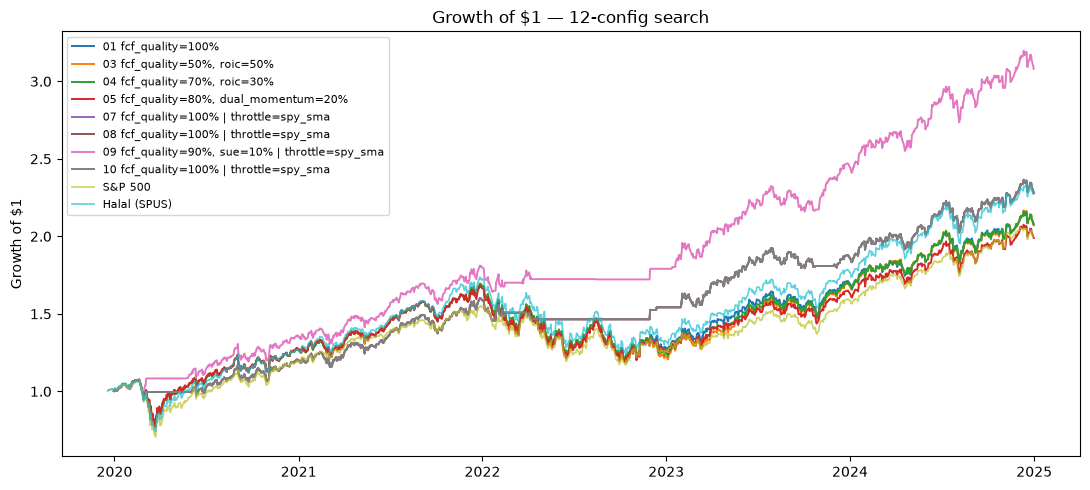

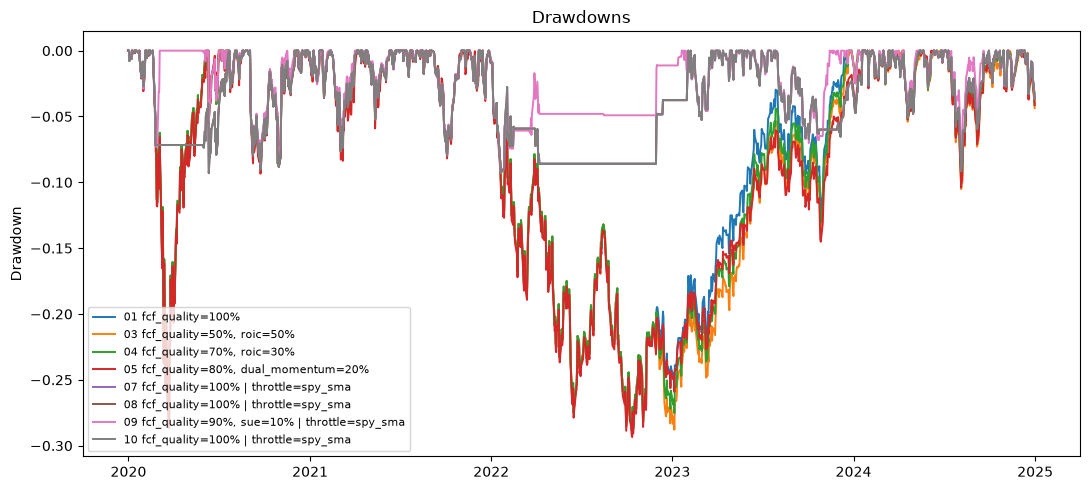

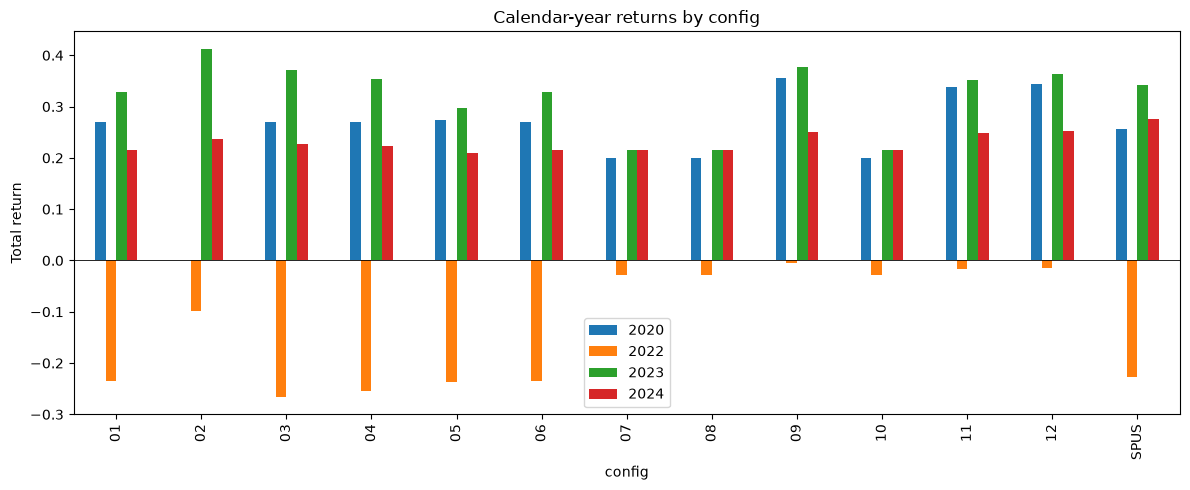

In [8]:
plot_nums = [1, 3, 4, 5, 7, 8, 9, 10]
labels = []
for row in results:
    if row["num"] in plot_nums or row["config"] == pick["config"]:
        labels.append(row["config"])
labels = list(dict.fromkeys(labels))

fig, ax = plt.subplots(figsize=(11, 5))
for lab_name in labels:
    s = series_map[lab_name].dropna()
    eq = (1 + s).cumprod()
    ax.plot(eq.index, eq.values, label=lab_name, linewidth=1.4)
for name, ticker in BENCHMARKS.items():
    s = bench_ret[ticker].dropna()
    s = s[(s.index >= pd.Timestamp(START)) & (s.index <= pd.Timestamp(END))]
    eq = (1 + s).cumprod()
    ax.plot(eq.index, eq.values, label=name, linewidth=1.2, alpha=0.7)
ax.set_title("Growth of $1 — 12-config search")
ax.set_ylabel("Growth of $1")
ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig(FIG_DIR / "equity-curves.png", dpi=140)
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
for lab_name in labels:
    s = series_map[lab_name].dropna()
    eq = (1 + s).cumprod()
    dd = eq / eq.cummax() - 1
    ax.plot(dd.index, dd.values, label=lab_name, linewidth=1.4)
ax.set_title("Drawdowns")
ax.set_ylabel("Drawdown")
ax.legend(fontsize=8, loc="lower left")
fig.tight_layout()
fig.savefig(FIG_DIR / "drawdowns.png", dpi=140)
plt.show()

cal = []
for row in results:
    cal.append(
        {
            "config": f"{int(row['num']):02d}",
            "2020": row["ret_2020"],
            "2022": row["ret_2022"],
            "2023": row["ret_2023"],
            "2024": row["ret_2024"],
        }
    )
cal.append({"config": "SPUS", "2020": spus["ret_2020"], "2022": spus["ret_2022"], "2023": spus["ret_2023"], "2024": spus["ret_2024"]})
cal_df = pd.DataFrame(cal).set_index("config")
ax = cal_df.plot(kind="bar", figsize=(12, 5), title="Calendar-year returns by config")
ax.set_ylabel("Total return")
ax.axhline(0, color="black", linewidth=0.6)
fig = ax.get_figure()
fig.tight_layout()
fig.savefig(FIG_DIR / "calendar-year-returns.png", dpi=140)
plt.show()


## How to read the pick

- If **#1 FCF 100%** wins, the multi-strategy story is not earning its complexity.
- If **#3 or #4** wins and Jaccard stays well below 50%, FCF+ROIC is a real mix; if Jaccard is high, it is one quality book with two labels.
- If **#5** fails test kill 4, dual momentum as a 20% sleeve is out — same failure as paper 07.
- If **#7 or #8** wins train *and* passes 2023, the brake belongs on **NAV** (paper 09), not inside 20% of the book.
- **#9 vs #10:** SUE only stays if it does not trip 2022/2023 kills. Do not raise SUE above 10% in this notebook.
- **#11/#12:** keep a cap only if top-5 drops and Calmar does not collapse.

Stop after this sheet. Do not add more weight triples.
